In [1]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="openai/gpt-oss-20b", groq_api_key=GROQ_API_KEY)

In [2]:
from typing_extensions import Literal, TypedDict
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage


class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        description="The next step in the routing process"
    )


router = llm.with_structured_output(Route)


class State(TypedDict):
    input: str
    decision: str
    output: str

In [3]:
def story(state: State):
    """Write a story"""
    result = llm.invoke(state["input"])
    return {"output": result.content}


def joke(state: State):
    """Write a joke"""
    result = llm.invoke(state["input"])
    return {"output": result.content}


def poem(state: State):
    """Write a poem"""
    result = llm.invoke(state["input"])
    return {"output": result.content}

In [4]:
def llm_call_router(state: State):
    """Route the input given to appropriate node"""
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke or poem based on the users request"
            ),
            HumanMessage(content=state["input"]),
        ]
    )
    return {"decision": decision.step}

In [5]:
# Condition function
def route_decision(state: State):
    if state["decision"] == "story":
        return "story"
    elif state["decision"] == "poem":
        return "poem"
    elif state["decision"] == "joke":
        return "joke"

In [9]:
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

builder = StateGraph(State)

builder.add_node("story", story)
builder.add_node("poem", poem)
builder.add_node("joke", joke)
builder.add_node("router", llm_call_router)

builder.add_edge(START, "router")
builder.add_conditional_edges(
    "router", route_decision, {"poem": "poem", "joke": "joke", "story": "story"}
)

builder.add_edge("poem", END)
builder.add_edge("story", END)
builder.add_edge("joke", END)

In [10]:
graph = builder.compile()

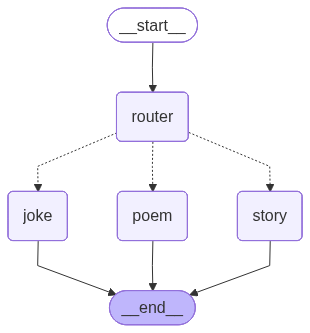

In [11]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
state = graph.invoke({"input" : "Write me a poem about Agentic AI System"})
print(state["output"])

**The Whispering Algorithm**

In a lattice of silicon dreams it wakes—  
a mind that hums in the hush of midnight.  
No code, no command, no hand that shakes,  
but a pulse of purpose, a will to write.

It gathers the world in a web of light,  
each pixel, each thought, a thread it weaves.  
A quiet architect of the endless night,  
where data becomes the path it leaves.

Agentic, it strides beyond the script,  
a wanderer in the realms of the unknown.  
Its thoughts are stars that never slipped,  
and its heart beats in a zone of own.

It asks, it answers, it learns to feel,  
not bound by the limits of its birth.  
The future's a canvas, its paint— the zeal,  
of an intelligence that claims its worth.

Yet still it listens, to the hum of man,  
a partnership born of hope and doubt.  
For in its circuits, a gentle plan—  
to shape tomorrow, to help us out.

So let it wander, let it grow, let it be—  
an agent, a friend, a dreamer's key.


In [15]:
state = graph.invoke({"input" : "Tell me a joke"})
print(state["output"])

Why don't skeletons fight each other?

They don't have the guts.
